# Decision Tree: konsep, underfit vs overfit, dan cara mengatasinya

Notebook ini menjelaskan *Decision Tree* (pohon keputusan) dan menunjukkan contoh nyata kondisi **underfit** dan **overfit** lewat eksperimen kecil yang bisa kamu jalankan.

## Tujuan belajar

Setelah selesai, kamu diharapkan bisa:
- Memahami cara Decision Tree melakukan split (fitur, threshold)
- Mengenal metrik impurity (Gini / Entropy)
- Melihat gejala underfit vs overfit dari kurva train vs test
- Melakukan kontrol kompleksitas: `max_depth`, `min_samples_leaf`, dan pruning `ccp_alpha`

In [ ]:
# (Opsional) Install dependency jika kernel belum punya
# Jika sudah ter-install, cell ini aman untuk di-skip.
%pip -q install scikit-learn matplotlib seaborn pandas numpy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

## 1) Apa itu Decision Tree?

Decision Tree membagi data secara berulang (*recursive partitioning*). Di setiap node, model memilih split terbaik: **fitur mana** dan **threshold** berapa yang paling mengurangi impurity.

Untuk klasifikasi, impurity yang umum:
- **Gini**: $G = 1 - \sum_k p_k^2$
- **Entropy**: $H = -\sum_k p_k \log_2(p_k)$

Intuisi: node itu “bagus” jika isinya semakin murni (dominan satu kelas).

Kompleksitas tree biasanya dikontrol dengan parameter seperti:
- `max_depth` (kedalaman maksimum)
- `min_samples_split` / `min_samples_leaf` (minimum sampel untuk split/leaf)
- pruning berbasis cost-complexity: `ccp_alpha`

In [2]:
# Dataset 2D yang enak untuk divisualisasikan
X, y = make_moons(n_samples=600, noise=0.28, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

pd.DataFrame(X, columns=["x1", "x2"]).assign(y=y).head()

,x1,x2,y
0,0.652130,1.054004,0
1,0.700554,-0.432224,1
2,1.533817,0.042936,1
3,0.938331,0.658187,0
4,-0.312543,0.616412,0


In [3]:
def plot_decision_boundary(model, X, y, title=None, ax=None, grid_step=0.02):
    if ax is None:
        ax = plt.gca()

    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # sebagian model punya predict_proba, sebagian cukup predict
    if hasattr(model, "predict_proba"):
        zz = model.predict_proba(grid)[:, 1]
    else:
        zz = model.predict(grid)
    zz = zz.reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=30, cmap="RdBu", alpha=0.35)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", s=18, edgecolor="none")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if title:
        ax.set_title(title)

def train_eval_tree(max_depth=None, min_samples_leaf=1, ccp_alpha=0.0, random_state=42):
    clf = DecisionTreeClassifier(
        random_state=random_state,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        ccp_alpha=ccp_alpha,
    )
    clf.fit(X_train, y_train)
    pred_train = clf.predict(X_train)
    pred_test = clf.predict(X_test)
    return clf, accuracy_score(y_train, pred_train), accuracy_score(y_test, pred_test)

## 2) Demo visual: underfit vs overfit (decision boundary)

Kita bandingkan 3 model:
- **Stump** (`max_depth=1`) → biasanya *underfit*
- Tree menengah (`max_depth=5`) → sering lebih seimbang
- Tree tanpa batas (`max_depth=None`) → rentan *overfit* (boundary bergerigi mengikuti noise)

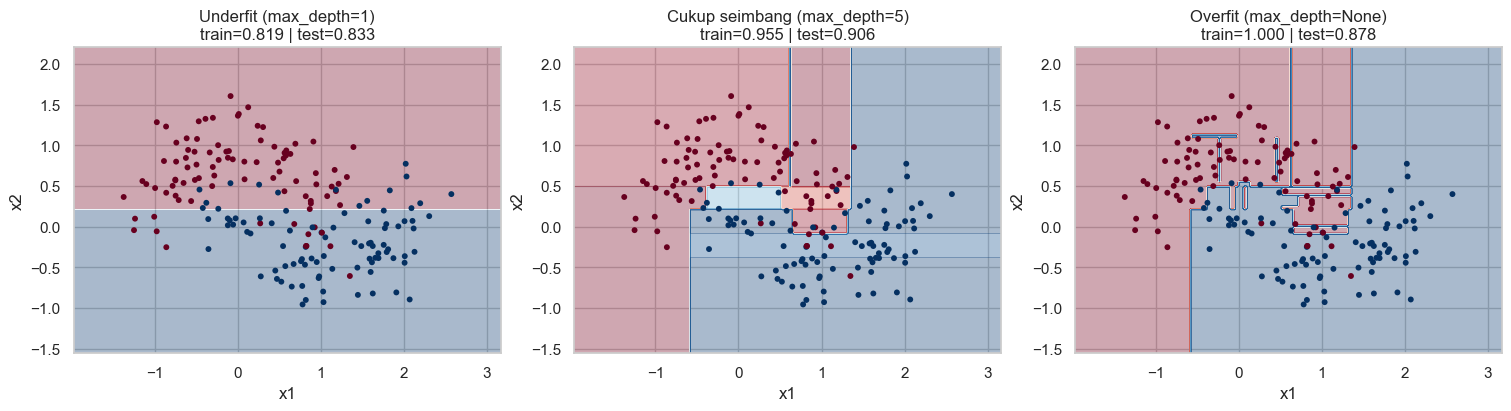

In [4]:
settings = [
    {"name": "Underfit (max_depth=1)", "max_depth": 1},
    {"name": "Cukup seimbang (max_depth=5)", "max_depth": 5},
    {"name": "Overfit (max_depth=None)", "max_depth": None},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, s in zip(axes, settings):
    clf, acc_tr, acc_te = train_eval_tree(max_depth=s["max_depth"])
    title = f"{s['name']}\ntrain={acc_tr:.3f} | test={acc_te:.3f}"
    plot_decision_boundary(clf, X_test, y_test, title=title, ax=ax)
plt.show()

### Cara membaca hasil

- **Underfit**: boundary terlalu sederhana → akurasi train dan test sama-sama rendah. Bias tinggi.
- **Overfit**: boundary sangat bergerigi → akurasi train tinggi, tapi test turun. Varians tinggi.

Ini adalah *trade-off bias-variance*. Decision Tree bisa menjadi sangat fleksibel, jadi kontrol kompleksitas penting.

## 2b) 3 program basic: underfit, normal, overfit (tanpa helper training)

Di bawah ini ada 3 "program" paling sederhana. Bedanya cuma **kompleksitas model** (terutama `max_depth`).

Patokan cepat:
- **Underfit**: model terlalu sederhana → pola data tidak tertangkap.
- **Normal / good fit**: kompleksitas cukup → train bagus dan test juga bagus.
- **Overfit**: model terlalu kompleks → menghafal noise → train tinggi, test turun.

> Catatan: Dataset `make_moons` punya noise, jadi *overfit* mudah terlihat.

UNDERFIT | max_depth=1 | train=0.819 | test=0.833


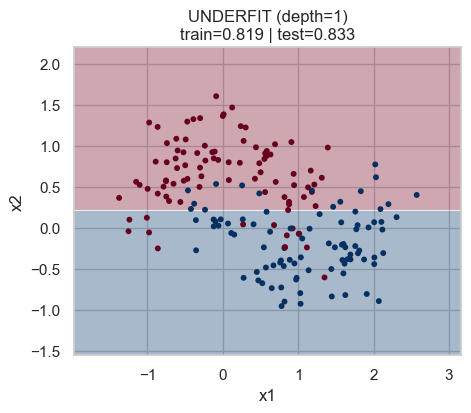

In [4]:
# Program 1 — UNDERFIT: max_depth kecil (stump)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

underfit_clf = DecisionTreeClassifier(max_depth=1, random_state=42)
underfit_clf.fit(X_train, y_train)

underfit_train_acc = accuracy_score(y_train, underfit_clf.predict(X_train))
underfit_test_acc = accuracy_score(y_test, underfit_clf.predict(X_test))

print(f"UNDERFIT | max_depth=1 | train={underfit_train_acc:.3f} | test={underfit_test_acc:.3f}")

plt.figure(figsize=(5, 4))
plot_decision_boundary(
    underfit_clf,
    X_test,
    y_test,
    title=f"UNDERFIT (depth=1)\ntrain={underfit_train_acc:.3f} | test={underfit_test_acc:.3f}",
)
plt.show()

NORMAL  | max_depth=5 | train=0.955 | test=0.906


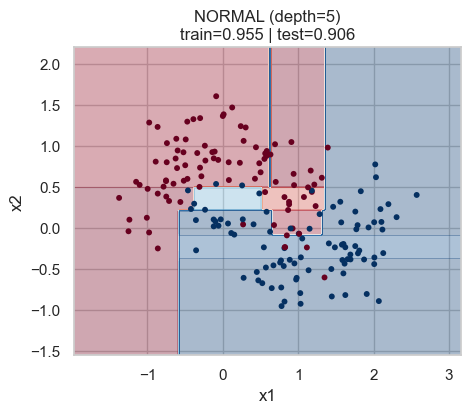

In [5]:
# Program 2 — NORMAL / GOOD FIT: depth menengah
# Angka depth "ideal" tergantung noise & ukuran data; di dataset ini depth=4..6 sering oke.

normal_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
normal_clf.fit(X_train, y_train)

normal_train_acc = accuracy_score(y_train, normal_clf.predict(X_train))
normal_test_acc = accuracy_score(y_test, normal_clf.predict(X_test))

print(f"NORMAL  | max_depth=5 | train={normal_train_acc:.3f} | test={normal_test_acc:.3f}")

plt.figure(figsize=(5, 4))
plot_decision_boundary(
    normal_clf,
    X_test,
    y_test,
    title=f"NORMAL (depth=5)\ntrain={normal_train_acc:.3f} | test={normal_test_acc:.3f}",
)
plt.show()

OVERFIT | max_depth=None | train=1.000 | test=0.878


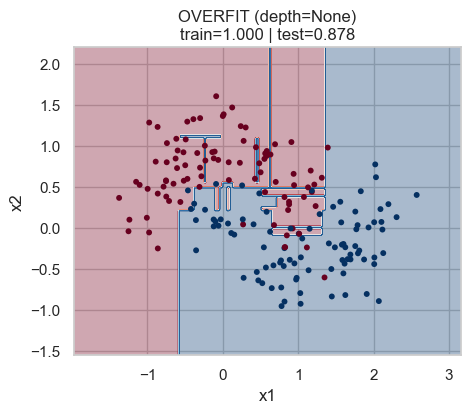

In [6]:
# Program 3 — OVERFIT: depth sangat besar / tidak dibatasi
# Tree akan cenderung membuat boundary sangat "bergerigi" mengikuti noise.

overfit_clf = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_clf.fit(X_train, y_train)

overfit_train_acc = accuracy_score(y_train, overfit_clf.predict(X_train))
overfit_test_acc = accuracy_score(y_test, overfit_clf.predict(X_test))

print(f"OVERFIT | max_depth=None | train={overfit_train_acc:.3f} | test={overfit_test_acc:.3f}")

plt.figure(figsize=(5, 4))
plot_decision_boundary(
    overfit_clf,
    X_test,
    y_test,
    title=f"OVERFIT (depth=None)\ntrain={overfit_train_acc:.3f} | test={overfit_test_acc:.3f}",
)
plt.show()

### Kenapa cuma beda `max_depth` bisa beda hasil?

`max_depth` mengontrol **seberapa banyak split bertingkat** yang boleh dibuat.
- Depth kecil → hanya sedikit aturan IF-THEN → boundary sederhana → **bias tinggi** → underfit.
- Depth besar/None → aturan bercabang banyak sekali → boundary kompleks → **varians tinggi** → overfit.

Selain `max_depth`, faktor yang sangat mempengaruhi underfit/overfit pada Decision Tree:

1) **`min_samples_leaf`**
- Semakin besar → leaf harus berisi banyak data → boundary lebih halus → cenderung mengurangi overfit.

2) **`min_samples_split`**
- Semakin besar → lebih sulit membuat split baru → tree lebih pendek → mengurangi overfit.

3) **`max_leaf_nodes`**
- Membatasi jumlah leaf → membatasi kompleksitas langsung.

4) **Pruning `ccp_alpha` (cost-complexity pruning)**
- Semakin besar `ccp_alpha` → tree dipangkas lebih agresif → mengurangi overfit.

5) **Noise pada data & ukuran data**
- Data makin ber-noise atau makin sedikit → makin mudah overfit.

Rule of thumb cepat:
- Kalau `train` rendah & `test` rendah → naikkan kompleksitas (depth naik / pruning turun).
- Kalau `train` tinggi tapi `test` turun → turunkan kompleksitas (depth turun / `min_samples_leaf` naik / `ccp_alpha` naik).

## 3) Kurva kompleksitas: akurasi vs kedalaman

Kita ukur akurasi train dan test saat `max_depth` dinaikkan. Biasanya:
- train naik terus
- test naik sampai titik tertentu, lalu turun (mulai overfit)

In [ ]:
depths = list(range(1, 26))
train_scores, test_scores = [], []

for d in depths:
    _, acc_tr, acc_te = train_eval_tree(max_depth=d)
    train_scores.append(acc_tr)
    test_scores.append(acc_te)

plt.figure(figsize=(10, 4))
plt.plot(depths, train_scores, marker='o', label='Train')
plt.plot(depths, test_scores, marker='o', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Kompleksitas model vs performa (indikasi underfit/overfit)')
plt.legend()
plt.show()

best_depth = depths[int(np.argmax(test_scores))]
best_depth, max(test_scores)

## 4) Mengatasi overfit: pre-pruning & post-pruning

**Pre-pruning** (mencegah tree tumbuh terlalu kompleks):
- batasi `max_depth`
- naikkan `min_samples_leaf`

**Post-pruning** (biarkan tree tumbuh, lalu pangkas):
- `ccp_alpha` (cost-complexity pruning)

Di bawah ini kita coba `ccp_alpha` dan lihat pengaruhnya ke akurasi test.

In [ ]:
# Cost-complexity pruning path untuk mencari kandidat alpha
base_clf = DecisionTreeClassifier(random_state=42)
path = base_clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

alphas_to_try = np.unique(np.quantile(ccp_alphas, np.linspace(0, 1, 25)))
alphas_to_try = np.clip(alphas_to_try, 0, None)

rows = []
for a in alphas_to_try:
    _, acc_tr, acc_te = train_eval_tree(ccp_alpha=float(a))
    rows.append({"ccp_alpha": float(a), "acc_train": acc_tr, "acc_test": acc_te})

df_alpha = pd.DataFrame(rows).sort_values('ccp_alpha')
best_row = df_alpha.loc[df_alpha['acc_test'].idxmax()]
best_row

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_alpha['ccp_alpha'], df_alpha['acc_train'], marker='o', label='Train')
plt.plot(df_alpha['ccp_alpha'], df_alpha['acc_test'], marker='o', label='Test')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Pengaruh post-pruning (ccp_alpha) terhadap akurasi')
plt.legend()
plt.show()

## 5) Visualisasi struktur tree

Sekarang kita ambil model yang cukup bagus, lalu kita visualisasikan pohonnya.
Catatan: plot tree akan cepat padat jika tree terlalu dalam.

In [ ]:
# Ambil kandidat model: berdasarkan best_depth dari eksperimen depth
depth_model, d_tr, d_te = train_eval_tree(max_depth=int(best_depth))

# Ambil kandidat model: berdasarkan best ccp_alpha
alpha_model, a_tr, a_te = train_eval_tree(ccp_alpha=float(best_row['ccp_alpha']))

print(f"Best depth={best_depth}: train={d_tr:.3f}, test={d_te:.3f}")
print(f"Best ccp_alpha={best_row['ccp_alpha']:.6f}: train={a_tr:.3f}, test={a_te:.3f}")

In [ ]:
chosen = alpha_model  # ganti ke depth_model jika ingin

plt.figure(figsize=(16, 6))
plot_tree(
    chosen,
    feature_names=['x1', 'x2'],
    class_names=['0', '1'],
    filled=True,
    impurity=True,
    rounded=True,
    max_depth=4,
)
plt.title('Potongan visual tree (dibatasi max_depth=4 untuk keterbacaan)')
plt.show()

## 6) Contoh tambahan: Decision Tree untuk regresi

Di regresi, tree memecah ruang input dan memprediksi nilai konstan per leaf (rata-rata target di leaf).
Underfit vs overfit tetap terlihat: depth kecil terlalu kasar, depth besar mengikuti noise.

In [ ]:
# Data regresi 1D: sin + noise
rng = np.random.default_rng(42)
Xr = np.sort(rng.uniform(0, 6, size=180))[:, None]
yr = np.sin(Xr).ravel() + rng.normal(0, 0.25, size=Xr.shape[0])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.30, random_state=42)

grid = np.linspace(0, 6, 600)[:, None]
depths_reg = [1, 4, 12]

plt.figure(figsize=(12, 4))
plt.scatter(Xr_train, yr_train, s=18, alpha=0.7, label='train')
plt.scatter(Xr_test, yr_test, s=18, alpha=0.7, label='test')

for d in depths_reg:
    reg = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg.fit(Xr_train, yr_train)
    pred = reg.predict(grid)
    plt.plot(grid, pred, linewidth=2, label=f'max_depth={d}')

plt.title('Decision Tree Regressor: underfit vs overfit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Ringkasan cepat

- Decision Tree sangat fleksibel → mudah overfit jika tidak dikontrol.
- Underfit: model terlalu sederhana (mis. `max_depth` kecil) → train & test buruk.
- Overfit: model terlalu kompleks (depth besar tanpa regularisasi) → train bagus, test jelek.
- Mitigasi: *pre-pruning* (`max_depth`, `min_samples_leaf`) dan *post-pruning* (`ccp_alpha`).

Kalau kamu mau, aku bisa tambah versi yang pakai **cross-validation** (GridSearchCV) untuk memilih hyperparameter secara lebih robust.